In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

from tqdm.auto import tqdm # used for progress bar

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [5]:
X = df[['sex','total_bill','day','smoker','tip','size']]
y= df[['time']]

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y, random_state=42,test_size=.25)


In [7]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop='first', sparse_output=False)

columns = ['sex','smoker','day']

# Fit on train
ohe.fit(X_train[columns])

# Transform
X_train_encoded = ohe.transform(X_train[columns])
X_test_encoded = ohe.transform(X_test[columns])

# Convert to DataFrame
encoded_cols = ohe.get_feature_names_out(columns)

X_train_ohe = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

# Drop original columns and concat
X_train = pd.concat([X_train.drop(columns, axis=1), X_train_ohe], axis=1)
X_test = pd.concat([X_test.drop(columns, axis=1), X_test_ohe], axis=1)

In [8]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder

# ct = ColumnTransformer(
#     transformers=[
#         ('ohe', OneHotEncoder(drop='first'), ['sex','smoker','day','time'])
#     ],
#     remainder='passthrough'
# )

# X_train = ct.fit_transform(X_train)
# X_test = ct.transform(X_test)

In [9]:
print(X_train.dtypes)

total_bill    float64
tip           float64
size            int64
sex_Male      float64
smoker_Yes    float64
day_Sat       float64
day_Sun       float64
day_Thur      float64
dtype: object


# GaussianNB

In [10]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train,y_train)

GaussianNB()

In [11]:
y_pred =gnb.predict(X_test)

In [12]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.9508196721311475
              precision    recall  f1-score   support

      Dinner       1.00      0.93      0.96        44
       Lunch       0.85      1.00      0.92        17

    accuracy                           0.95        61
   macro avg       0.93      0.97      0.94        61
weighted avg       0.96      0.95      0.95        61

[[41  3]
 [ 0 17]]


In [13]:
y_test['time'].value_counts()

time
Dinner    44
Lunch     17
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(gnb, X_train, y_train, cv=5)
print(scores.mean())

0.9453453453453454


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

param_gnb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

grid_gnb = GridSearchCV(
    GaussianNB(),
    param_gnb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gnb.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GaussianNB(), n_jobs=-1,
             param_grid={'var_smoothing': [1e-09, 1e-08, 1e-07]},
             scoring='accuracy')

# BernoulliNB

In [16]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train, y_train)

BernoulliNB()

In [17]:
from sklearn.naive_bayes import BernoulliNB

param_bnb = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}

grid_bnb = GridSearchCV(
    BernoulliNB(),
    param_bnb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_bnb.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=BernoulliNB(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.5, 1.0, 2.0]}, scoring='accuracy')

# Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
from sklearn.linear_model import LogisticRegression

param_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

# Comparision gnb vs bnb vs log_reg

| Model        | Best For                         |
| ------------ | -------------------------------- |
| GaussianNB   | Continuous (normal distribution) |
| BernoulliNB  | Binary features (0/1)            |
| Logistic Reg | General-purpose strong baseline  |


In [20]:
print("GaussianNB:", gnb.score(X_test, y_test))
print("BernoulliNB:", bnb.score(X_test, y_test))
print("Logistic:", lr.score(X_test, y_test))

GaussianNB: 0.9508196721311475
BernoulliNB: 1.0
Logistic: 1.0


In [21]:
print("GaussianNB Best:", grid_gnb.best_score_, grid_gnb.best_params_)
print("BernoulliNB Best:", grid_bnb.best_score_, grid_bnb.best_params_)
print("Logistic Best:", grid_lr.best_score_, grid_lr.best_params_)

GaussianNB Best: 0.9453453453453454 {'var_smoothing': 1e-09}
BernoulliNB Best: 0.956006006006006 {'alpha': 0.1}
Logistic Best: 0.945045045045045 {'C': 1, 'solver': 'lbfgs'}


In [22]:
print("GaussianNB:", grid_gnb.score(X_test, y_test))
print("BernoulliNB:", grid_bnb.score(X_test, y_test))
print("Logistic:", grid_lr.score(X_test, y_test))

GaussianNB: 0.9508196721311475
BernoulliNB: 1.0
Logistic: 1.0


# Learning Curve

In [31]:
#Generate Learning Curves

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=bnb,   # you can use gnb / bnb / lr
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

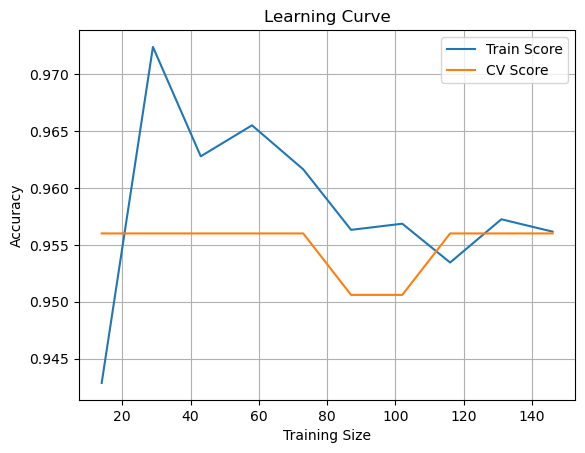

In [32]:
#plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, val_mean, label="CV Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()

plt.show()

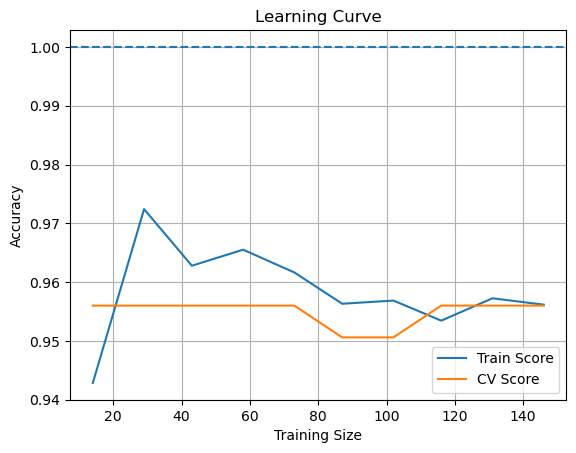

In [37]:
#plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, val_mean, label="CV Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()


# Add Test Score

test_score = lr.score(X_test, y_test)

plt.axhline(y=test_score, linestyle='--', label="Test Score")

plt.show()

📊 What we see:
Train score ≈ 0.96–0.97
CV score ≈ 0.95–0.96
Gap is very small
🧠 Interpretation:

✅ Well-balanced model
✅ Very low overfitting
✅ Stable across dataset sizes

⚠️ Observation:
Plateau early → model not learning more with more data
🎯 Verdict:

👉 Good generalization, but slightly limited capacity

### gnb


In [38]:
#Generate Learning Curves

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=gnb,   # you can use gnb / bnb / lr
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

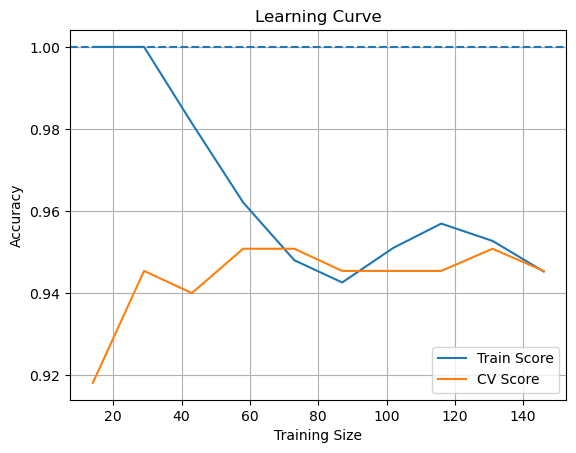

In [39]:
#plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, val_mean, label="CV Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()


# Add Test Score

test_score = lr.score(X_test, y_test)

plt.axhline(y=test_score, linestyle='--', label="Test Score")

plt.show()

📊 What we see:
Train score starts at 1.0 🔥
CV score much lower (~0.92–0.95)
Gap large initially, then shrinks
🧠 Interpretation:

🚨 Overfitting at small data sizes
📉 High variance model behavior
📈 Improves as data increases

🎯 Key Insight:
Model memorizes small data
Needs more data to stabilize
🎯 Verdict:

👉 Okay model, but unstable + assumption mismatch (Gaussian vs binary data)

# lr

In [40]:
#Generate Learning Curves

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    estimator=lr,   # you can use gnb / bnb / lr
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

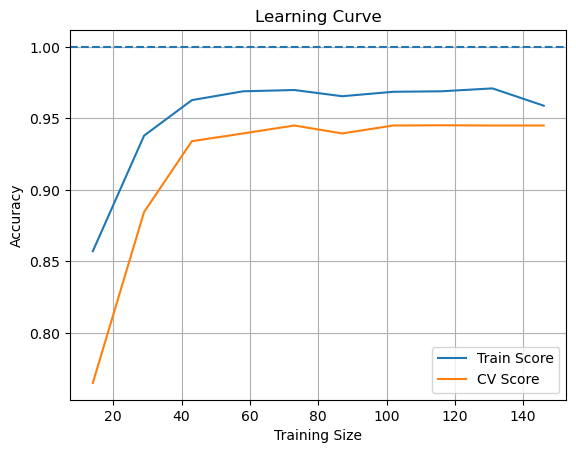

In [41]:
#plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, val_mean, label="CV Score")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()


# Add Test Score

test_score = lr.score(X_test, y_test)

plt.axhline(y=test_score, linestyle='--', label="Test Score")

plt.show()

📊 What we see:
Train ≈ 0.96–0.97
CV ≈ 0.94–0.95
Small, consistent gap
🧠 Interpretation:

✅ Best balance of bias & variance
✅ Smooth learning curve
✅ Improves steadily with data

⚡ Important:
No sharp drops or instability
No strong overfitting
🎯 Verdict:

👉 Best model among the three

| Model        | Overfitting | Stability | Performance | Verdict      |
| ------------ | ----------- | --------- | ----------- | ------------ |
| BernoulliNB  | Low         | High      | Medium      | 👍 Good      |
| GaussianNB   | High        | Medium    | Medium      | ⚠️ Not ideal |
| Logistic Reg | Low         | High      | High        | 🏆 Best      |
